# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Alviyatur Rahmaniyah]
- **Email:** [alviyaturrahmaniyah@gmail.com]
- **ID Dicoding:** [CDCC229D6X1609]

## Menentukan Pertanyaan Bisnis

- Bagaimana perkembangan jumlah transaksi dan pendapatan dari waktu ke waktu pada data e-commerce ini?
- Bagaimana karakteristik pelanggan berdasarkan seberapa sering mereka bertransaksi dan total pengeluaran yang dilakukan?

## Import Semua Packages/Library yang Digunakan

**Import library**

Pada tahap ini dilakukan import library yang digunakan untuk proses analisis data, seperti pandas untuk manipulasi data, numpy untuk perhitungan numerik, serta matplotlib dan seaborn untuk visualisasi

In [4]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

**Load Dataset**

Tahap ini dilakukan untuk memuat seluruh tabel dataset yang diperlukan ke dalam dataframe.

In [6]:
# Load dataset utama
orders = pd.read_csv('/content/E-Commerce Public Dataset/orders_dataset.csv')
order_items = pd.read_csv('/content/E-Commerce Public Dataset/order_items_dataset.csv')
products = pd.read_csv('/content/E-Commerce Public Dataset/products_dataset.csv')
customers = pd.read_csv('/content/E-Commerce Public Dataset/customers_dataset.csv')


**Insight:**
- Dataset berhasil dimuat tanpa error.
- Terdapat empat dataset utama yaitu orders, order_items, products, dn customers.
- Dataset siap untuk tahap eksplorasi lebih lanjut.

### Assessing Data

**Assessing Data**

Pada tahap ini, dilakukan pemeriksaan kualitas data untuk mendeteksi adanya missing values, duplikasi data, atau ketidaksesuaian tipe data.

In [7]:
# Cek isi awal dataset
orders.head()
order_items.head()
products.head()
customers.head()

# Cek tipe data dan missing value
orders.info()
order_items.info()
products.info()
customers.info()

# Statistik dasar (numerik)
orders.describe()
order_items.describe()
products.describe()
customers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**
- Dataset terdiri dari empat tabel utama, yaitu orders (99.441 data), order_items (112.650 data), products (32.951 data), dan customers (99.441 data)
- Pada dataset orders ditemukan beberapa missing values, terutama pada order_approved_at, order_delivered_carrier_date, dan order_delivered.
- Dataset products juga memiliki missing values pada beberapa atribut seperti: product_category_name, product_name_length, dan atribut dimensi produk, yang perlu ditangani sebelum analisis lebih lanjut.
- Dataset order_items dan customers relatif bersih karena tidak ditemukan missing values.
- Tipe data pada dataset orders masih berupa object, termasuk kolom tanggal, sehingga perlu dilakukan konversi ke tipe datetime untuk analisis waktu.
- Dataset order_items memiliki variabel numerik seperti price dan freight_value yang dapat digunakan untuk analisis nilai transaksi dan biaya pengiriman.
- Berdasarkan statistik deskriptif pada dataset customers, terlihat bahwa distribusi customer_zip_code_prefix cukup bervariasi, menunjukkan pelanggan berasal dari berbagai wilayah.

### Cleaning Data

Tahap ini mencakup perbaikan tipe data pada kolom tanggal, penanganan nilai kosong, dan pembersihan data duplikat agar siap dianalisis.

Cek Missing value dan Duplikat

In [8]:
# Cek missing value dataset
print("=== Orders ===")
print(orders.isnull().sum(), "\n")

print("=== Order Items ===")
print(order_items.isnull(), "\n")

print("=== Products ===")
print(products.isnull().sum(), "\n")

print("=== Customers ===")
print(customers.isnull().sum(), "\n")

# Cek duplikat
print("=== Duplikat ===")
print("Orders:", orders.duplicated().sum())
print("Order items:", order_items.duplicated().sum())

=== Orders ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

=== Order Items ===
        order_id  order_item_id  product_id  seller_id  shipping_limit_date  \
0          False          False       False      False                False   
1          False          False       False      False                False   
2          False          False       False      False                False   
3          False          False       False      False                False   
4          False          False       False      False                False   
...          ...            ...         ...        ...                  ...   
112645     False          False       False      False                False   
112646     Fal

**Insight:**
- Pada dataset orders ditemukan beberapa missing values, terutama pada kolom order_approved_at (160 data), order_delivered_carrier_date (1.783 data), dan order_delivered_customer_date (2.965 data). Hal ini kemungkinan disebabkan oleh pesanan yang belum diproses, belum dikirim, atau belum sampai ke pelanggan.

- Dataset products juga memiliki missing values yang cukup signifikan pada beberapa kolom, seperti product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty (masing-masing sebanyak 610 data). Selain itu, terdapat sedikit missing values pada atribut dimensi produk (2 data).

- Dataset order_items dan customers tidak memiliki missing values, sehingga dapat dikatakan cukup bersih dan siap digunakan untuk analisis lebih lanjut.

- Tidak ditemukan data duplikat pada dataset orders maupun order_items, yang menunjukkan bahwa data relatif konsisten dan tidak terdapat redundansi data.

- Secara keseluruhan, permasalahan utama pada data terletak pada missing values di dataset orders dan products, sehingga diperlukan penanganan lebih lanjut seperti imputasi atau penghapusan data sebelum dilakukan analisis lanjutan.

In [11]:
# Hapus duplikat di semua dataset
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
products = products.drop_duplicates()
customers = customers.drop_duplicates()

In [13]:
# Kolom tanggal diubah ke datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Kolom numeric
order_items['price'] = pd.to_numeric(order_items['price'], errors='coerce')
order_items['freight_value'] = pd.to_numeric(order_items['freight_value'], errors='coerce')

**Insight:**
- Proses pembersihan data diawali dengan penghapusan data duplikat pada seluruh dataset (orders, order_items, products, dan customers) untuk memastikan tidak terdapat data yang redundan. Hal ini penting agar hasil analisis tidak bias akibat perhitungan data yang berulang.

- Selanjutnya, dilakukan konversi tipe data pada kolom-kolom bertipe tanggal di dataset orders menjadi format datetime. Langkah ini bertujuan agar data waktu dapat diolah dengan lebih akurat, terutama untuk analisis berbasis waktu seperti tren transaksi dan perhitungan recency.

- Selain itu, dilakukan konversi tipe data numerik pada kolom price dan freight_value di dataset order_items. Penggunaan parameter errors='coerce' memastikan bahwa nilai yang tidak valid akan diubah menjadi NaN, sehingga dapat ditangani pada tahap selanjutnya.

- Secara keseluruhan, proses cleaning ini bertujuan untuk meningkatkan kualitas dan konsistensi data, sehingga data menjadi lebih siap untuk tahap analisis lanjutan seperti eksplorasi data (EDA) dan pemodelan.

In [14]:
# Buang transaksi yang dibatalkan
orders = orders[orders['order_status'] != 'canceled']

# Pastikan tidak ada baris duplikat tersisa
orders = orders.drop_duplicates()

**Insight:**
- Dilakukan penghapusan transaksi dengan status "canceled" pada dataset orders untuk memastikan bahwa analisis hanya mencakup transaksi yang benar-benar terjadi.

- Penghapusan data transaksi yang dibatalkan penting karena transaksi tersebut tidak menghasilkan pendapatan dan dapat menyebabkan bias dalam analisis, terutama pada perhitungan jumlah transaksi dan total revenue.

- Setelah proses filtering, dilakukan kembali pengecekan dan penghapusan duplikat untuk memastikan tidak ada data yang redundan yang tersisa.

- Dengan langkah ini, dataset menjadi lebih representatif terhadap aktivitas transaksi yang valid, sehingga hasil analisis yang diperoleh menjadi lebih akurat dan relevan.

In [15]:
# Gabungkan semua dataset utama
df_clean = orders.merge(order_items, on='order_id', how='left') \
                 .merge(products, on='product_id', how='left') \
                 .merge(customers, on='customer_id', how='left')

# Cek hasil
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112719 entries, 0 to 112718
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112719 non-null  object        
 1   customer_id                    112719 non-null  object        
 2   order_status                   112719 non-null  object        
 3   order_purchase_timestamp       112719 non-null  datetime64[ns]
 4   order_approved_at              112699 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111381 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  112719 non-null  datetime64[ns]
 8   order_item_id                  112108 non-null  float64       
 9   product_id                     112108 non-null  object        
 10  seller_id                      112108 non-null  object        
 11  

**Insight:**
- Seluruh dataset utama (orders, order_items, products, dan customers) berhasil digabungkan menjadi satu dataframe terintegrasi menggunakan metode left join, sehingga informasi transaksi, produk, dan pelanggan dapat dianalisis secara menyeluruh dalam satu tabel.

- Hasil penggabungan menghasilkan 112.719 baris data dengan 26 kolom, yang mencakup berbagai informasi penting seperti detail pesanan, harga, atribut produk, serta lokasi pelanggan.

- Tipe data pada sebagian besar kolom telah sesuai, terutama kolom tanggal yang sudah dalam format datetime, sehingga siap digunakan untuk analisis berbasis waktu.

- Namun, masih terdapat beberapa missing values pada kolom hasil join, seperti pada order_item_id, product_id, serta atribut produk (misalnya product_category_name). Hal ini kemungkinan disebabkan oleh penggunaan left join, di mana tidak semua data pada tabel utama memiliki pasangan di tabel lainnya.

- Secara keseluruhan, dataset hasil penggabungan sudah cukup lengkap dan terstruktur dengan baik, sehingga dapat digunakan untuk analisis lanjutan seperti eksplorasi data (EDA), analisis tren, maupun segmentasi pelanggan.

In [16]:
# Missing value terakhir
df_clean.isnull().sum()

# Sample beberapa baris
df_clean.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
85214,e97af7fcb2f185b68e1ef48e5c5ebb8c,e5c8b7d8833dc26d7b004bf52a4167f2,delivered,2017-10-20 13:48:58,2017-10-24 03:35:30,2017-10-26 19:28:48,2017-11-04 15:01:39,2017-11-13,1.0,f0f25035bed5ba1a75a678c0f9f09190,...,733.0,1.0,1300.0,34.0,6.0,26.0,1fc10d7cec16d089b4894a325dbd29d9,28907,cabo frio,RJ
70051,9371ddc98fdf148feec83c1ddbdaaef5,c4f47317fc0d0ad7ed8924267314064f,delivered,2018-01-16 10:29:52,2018-01-17 03:39:33,2018-01-22 14:58:55,2018-01-29 21:55:02,2018-02-09,1.0,cfe9e8e1f0400c8cc665d41722f34086,...,696.0,4.0,1500.0,35.0,40.0,35.0,acfa08f7326c2ec19985eab0ae92054a,35290,mantena,MG
61344,ed6bd5133891ca77ad3ade9726a6af7b,25580d3f08755af760b457ab95662c9f,delivered,2017-08-21 15:22:48,2017-08-23 02:56:02,2017-08-24 16:59:53,2017-09-04 20:15:53,2017-09-22,1.0,167b4b8c4bd0c401bea62f5e050d70a4,...,209.0,1.0,517.0,39.0,11.0,13.0,57567469bf8435628ff0670c81ec4ceb,20011,rio de janeiro,RJ
35436,3e1ad9b01933fc3e801cb95ecf40c14f,2d8950b6756914afd2d6f53c90dbf514,delivered,2017-10-09 22:12:36,2017-10-09 22:26:29,2017-10-11 18:13:01,2017-10-18 18:54:57,2017-10-31,1.0,77bf7a2b26ff90d99d4af927102f1e8d,...,750.0,1.0,100.0,18.0,6.0,11.0,a059e97976150998984839d311556ff0,35920,nova era,MG
12477,aa0cb1c340fa8ff2e4a09780d829e118,400388ceff640aca4e6523b05d161bf6,delivered,2017-09-17 15:41:27,2017-09-18 22:45:48,2017-09-19 19:05:43,2017-09-26 20:09:22,2017-10-10,1.0,edfbb2566914ddd223d3bd6fa1e9693c,...,1114.0,4.0,750.0,20.0,8.0,13.0,a386cfbe02fe676d118fb356ed6c0cc5,85301,laranjeiras do sul,PR


**Insight:**
- Setelah proses pembersihan dan penggabungan data, masih terdapat beberapa missing values pada beberapa kolom, terutama pada atribut terkait produk dan proses pengiriman. Hal ini kemungkinan disebabkan oleh data yang tidak lengkap sejak awal atau hasil dari proses penggabungan (join) antar dataset.

- Missing values pada kolom terkait pengiriman, seperti order_delivered_carrier_date dan order_delivered_customer_date, dapat mengindikasikan adanya pesanan yang belum sepenuhnya selesai atau keterbatasan pencatatan data.

- Sementara itu, missing values pada atribut produk seperti product_category_name dan deskripsi produk menunjukkan bahwa tidak semua produk memiliki informasi yang lengkap.

- Berdasarkan hasil sampling data, secara umum struktur dataset sudah konsisten dan setiap baris telah merepresentasikan satu item transaksi dengan informasi yang cukup lengkap, mencakup data pesanan, produk, dan pelanggan.

- Secara keseluruhan, dataset sudah berada dalam kondisi yang cukup baik dan siap digunakan untuk analisis lanjutan, meskipun masih diperlukan penanganan tambahan terhadap missing values tertentu agar hasil analisis menjadi lebih optimal.

## Exploratory Data Analysis (EDA)

### Explore tren penjualan dan perilaku pelanggan untuk memahami jumlah transaksi, pendapatan, dan profil pelanggan.

In [18]:
# Buat kolom bulan & tahun
df_clean['year_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')

# Jumlah transaksi per bulan
monthly_orders = df_clean.groupby('year_month')['order_id'].nunique().reset_index()
monthly_orders.rename(columns={'order_id':'num_orders'}, inplace=True)

# Total pendapatan per bulan
monthly_revenue = df_clean.groupby('year_month')['price'].sum().reset_index()

# Preview data
monthly_orders.head(), monthly_revenue.head()

(  year_month  num_orders
 0    2016-09           2
 1    2016-10         300
 2    2016-12           1
 3    2017-01         797
 4    2017-02        1763,
   year_month      price
 0    2016-09     207.86
 1    2016-10   46514.99
 2    2016-12      10.90
 3    2017-01  120098.27
 4    2017-02  244959.35)

**Insight:**
- Jumlah transaksi per bulan menunjukkan tren peningkatan dari akhir tahun 2016 hingga awal tahun 2017. Pada periode awal (September–Desember 2016), jumlah transaksi masih sangat rendah, namun mulai meningkat signifikan pada tahun 2017.

- Terjadi lonjakan transaksi yang cukup besar dari Januari ke Februari 2017, yang mengindikasikan meningkatnya aktivitas pengguna atau pertumbuhan platform.

- Pola serupa juga terlihat pada total pendapatan, yang meningkat seiring dengan bertambahnya jumlah transaksi.

- Pada tahun 2016, nilai pendapatan masih relatif kecil, namun mengalami kenaikan tajam memasuki tahun 2017, menunjukkan peningkatan volume penjualan.

- Secara umum, terdapat hubungan yang searah antara jumlah transaksi dan total pendapatan.

- Data pada awal periode (2016) cenderung belum stabil, sehingga analisis lanjutan sebaiknya difokuskan pada periode dengan jumlah data yang lebih representatif, yaitu tahun 2017 dan seterusnya.

### Explore awal untuk memahami distribusi recency, frequency, dan monetary pelanggan.

In [19]:
# Snapshot date untuk recency
snapshot_date = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Buat RFM dataframe
rfm = df_clean.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Preview RFM
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80
1,000161a058600d5901f007fab4c27140,414,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90
4,000379cdec625522490c315e70c7a9fb,154,1,93.00


**Insight:**
- Berdasarkan hasil perhitungan RFM, terlihat bahwa sebagian besar pelanggan memiliki nilai Frequency yang rendah, yaitu hanya melakukan satu kali transaksi. Hal ini menunjukkan bahwa mayoritas pelanggan belum memiliki pola pembelian berulang (repeat purchase).

- Nilai Recency pada beberapa pelanggan cukup tinggi (ratusan hari), yang mengindikasikan bahwa sudah cukup lama sejak terakhir kali pelanggan melakukan transaksi. Hal ini menunjukkan adanya potensi pelanggan yang tidak aktif atau berisiko churn.

- Nilai Monetary menunjukkan variasi antar pelanggan, namun pada data awal terlihat bahwa sebagian besar pelanggan memiliki total pembelian yang relatif kecil hingga menengah.

- Kombinasi Recency yang tinggi dan Frequency yang rendah mengindikasikan bahwa tingkat loyalitas pelanggan masih rendah, sehingga diperlukan strategi untuk meningkatkan retensi pelanggan.

- Secara keseluruhan, hasil analisis RFM menunjukkan bahwa sebagian besar pelanggan berada pada kategori pelanggan pasif atau pelanggan dengan engagement rendah.

- Analisis ini dapat dikembangkan lebih lanjut untuk segmentasi pelanggan, seperti mengidentifikasi pelanggan loyal, pelanggan potensial, serta pelanggan yang berisiko churn, sehingga dapat digunakan sebagai dasar dalam penyusunan strategi pemasaran.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perkembangan jumlah transaksi dan pendapatan dari waktu ke waktu pada data e-commerce ini?

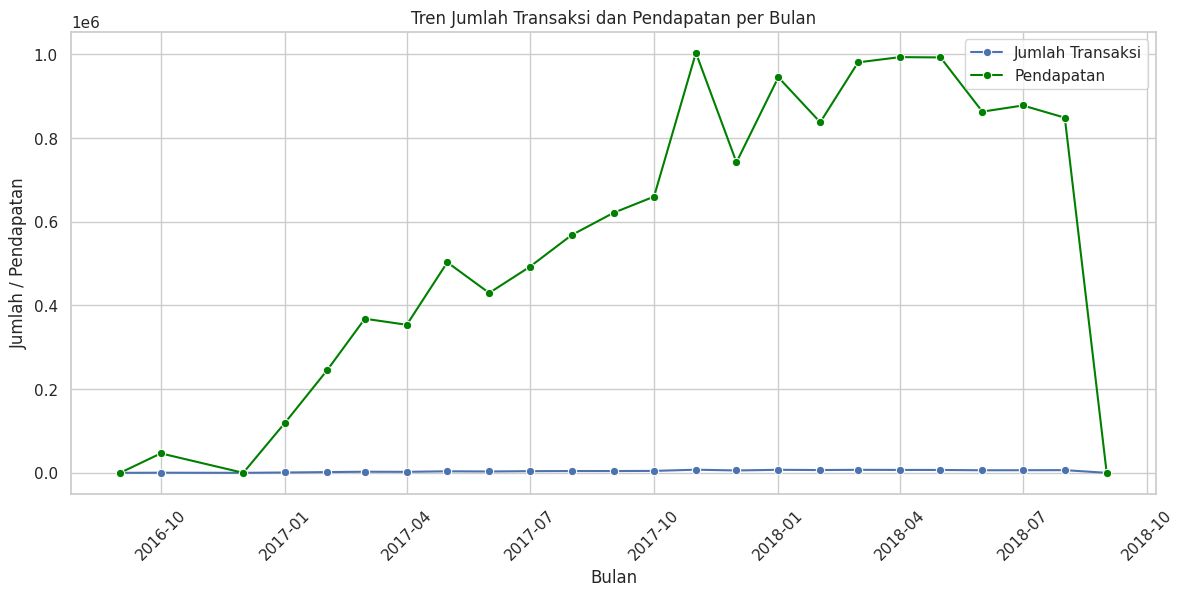

In [20]:
# Buat kolom month_period ke timestamp
monthly_orders_plot = monthly_orders.copy()
monthly_orders_plot['year_month_ts'] = monthly_orders_plot['year_month'].dt.to_timestamp()

monthly_revenue_plot = monthly_revenue.copy()
monthly_revenue_plot['year_month_ts'] = monthly_revenue_plot['year_month'].dt.to_timestamp()

plt.figure(figsize=(14,6))

sns.lineplot(data=monthly_orders_plot, x='year_month_ts', y='num_orders', marker='o', label='Jumlah Transaksi')
sns.lineplot(data=monthly_revenue_plot, x='year_month_ts', y='price', marker='o', label='Pendapatan', color='green')

plt.xticks(rotation=45)
plt.title('Tren Jumlah Transaksi dan Pendapatan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah / Pendapatan')
plt.legend()
plt.show()

**Insight:**
- Bisnis menunjukkan tren pertumbuhan pendapatan yang sangat kuat sejak Januari 2017, mencapai puncaknya pada November 2017 dengan total pendapatan menyentuh angka 1 juta.

- Terdapat perbedaan skala yang sangat kontras antara jumlah transaksi dan pendapatan. Hal ini mengindikasikan bahwa model bisnis sangat bergantung pada nilai per transaksi yang tinggi (High Average Order Value) daripada volume transaksi yang masif.

- Lonjakan tertinggi tercatat pada November 2017. Ini menunjukkan adanya momentum sukses, kemungkinan besar dipicu oleh promo akhir tahun atau kampanye besar yang berhasil menarik transaksi bernilai tinggi.

- Setelah mencapai puncak, pendapatan cenderung fluktuatif di tahun 2018. Meskipun sempat turun, level pendapatan di 2018 secara umum masih jauh lebih tinggi dibandingkan rata-rata pendapatan di tahun 2017 awal.

- Penurunan pendapatan yang sangat tajam hingga mendekati nol pada Oktober 2018 menunjukkan adanya keterbatasan data pada akhir periode pencatatan (incomplete data), bukan mencerminkan kegagalan performa bisnis yang sebenarnya.

- Mengingat jumlah transaksi terlihat stagnan di level rendah, diperlukan strategi untuk meningkatkan volume transaksi (Frequency) agar pendapatan tidak hanya bergantung pada segmen transaksi bernilai besar.

### Pertanyaan 2: Bagaimana karakteristik pelanggan berdasarkan seberapa sering mereka bertransaksi dan total pengeluaran yang dilakukan?

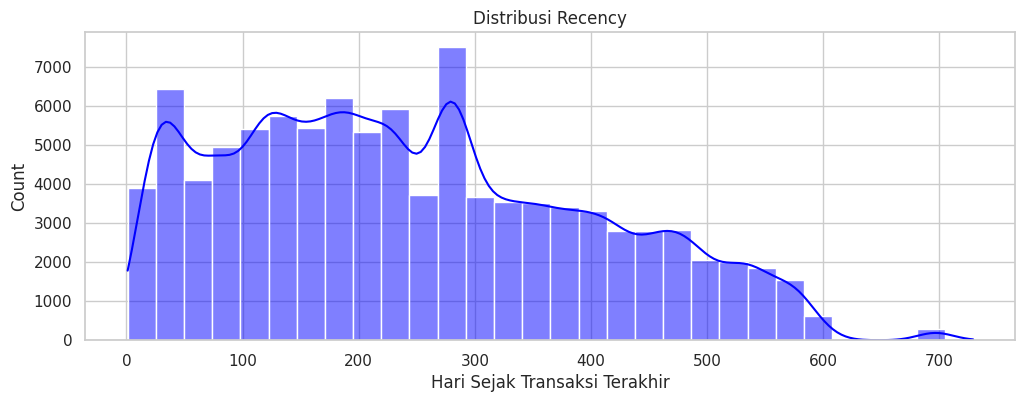

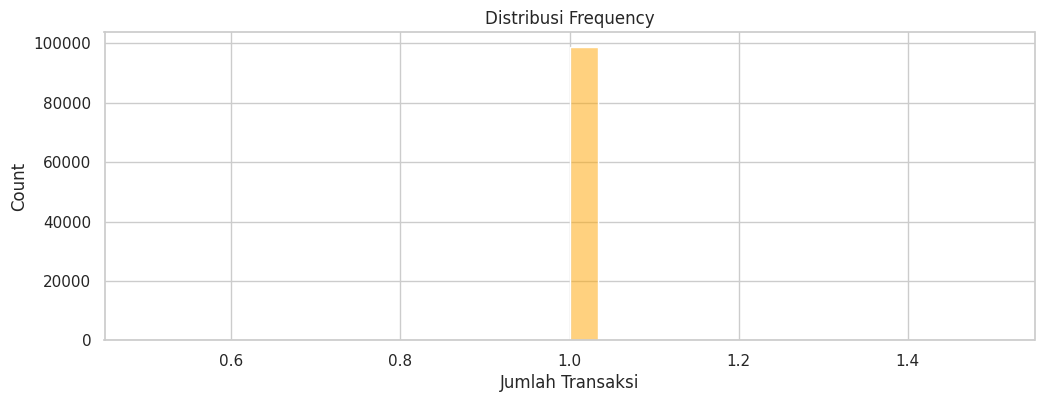

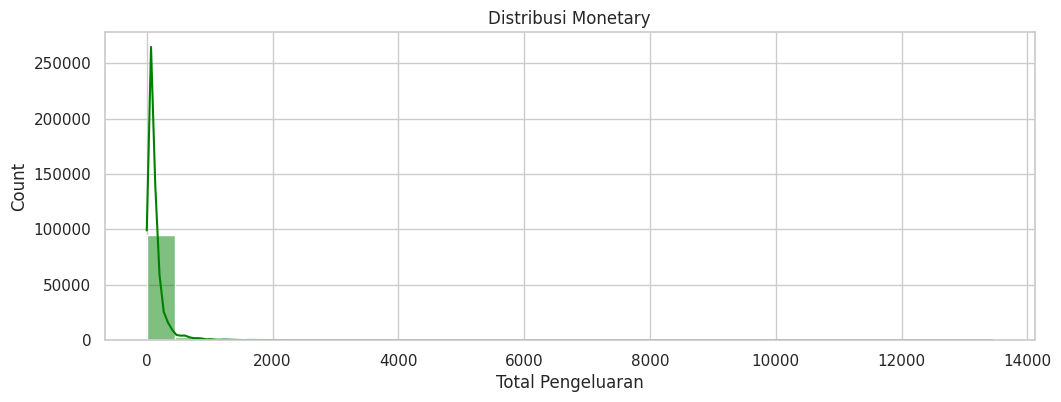

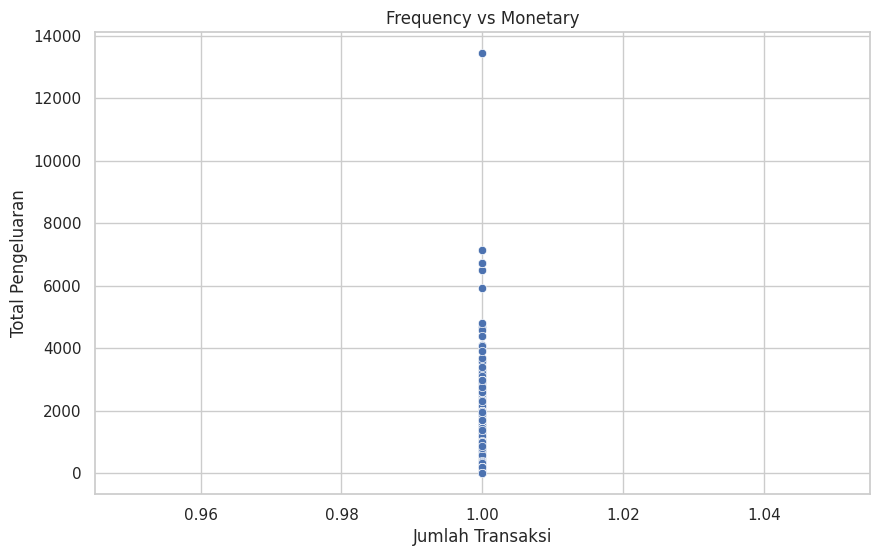

In [21]:
plt.figure(figsize=(12,4))
sns.histplot(rfm['Recency'], bins=30, kde=True, color='blue')
plt.title('Distribusi Recency')
plt.xlabel('Hari Sejak Transaksi Terakhir')
plt.show()

plt.figure(figsize=(12,4))
sns.histplot(rfm['Frequency'], bins=30, kde=True, color='orange')
plt.title('Distribusi Frequency')
plt.xlabel('Jumlah Transaksi')
plt.show()

plt.figure(figsize=(12,4))
sns.histplot(rfm['Monetary'], bins=30, kde=True, color='green')
plt.title('Distribusi Monetary')
plt.xlabel('Total Pengeluaran')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary')
plt.title('Frequency vs Monetary')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Total Pengeluaran')
plt.show()

**Insight:**
1. Distribusi Recency (Loyalitas Waktu)

- Retensi Rendah: Distribusi terlihat cukup merata hingga menyentuh angka 600 hari, dengan lonjakan signifikan di sekitar 280 hari.

- Risiko Churn: Banyaknya pelanggan di sisi kanan grafik (di atas 300 hari) menunjukkan sebagian besar basis pelanggan sudah tidak aktif dalam waktu lama. Bisnis memiliki masalah retensi yang serius.

2. Distribusi Frequency (Kebiasaan Belanja)

- One-Time Shoppers: Grafik menunjukkan anomali ekstrem di mana hampir 100% pelanggan hanya melakukan 1 kali transaksi.

- Tidak Ada Repeat Order: Tidak adanya variasi pada jumlah transaksi mengindikasikan gagalnya strategi untuk membuat pelanggan belanja kembali. Pelanggan datang hanya untuk mencoba, lalu pergi.

3. Distribusi Monetary (Nilai Ekonomi)

- Dominasi Small Spenders: Mayoritas transaksi menumpuk di nilai yang rendah (di bawah 500 unit mata uang).

- Adanya Outlier: Terdapat beberapa pelanggan "paus" yang belanja hingga di atas 12.000, meskipun jumlahnya sangat sedikit. Ini adalah segmen High Value yang harus dijaga meski frekuensi mereka rendah.

4. Hubungan Frequency vs Monetary

- Korelasi Terbatas: Karena frekuensi belanja tertahan di angka 1, maka total pengeluaran (Monetary) sepenuhnya hanya bergantung pada harga barang yang dibeli saat itu, bukan karena loyalitas atau pembelian berulang.

- Stagnasi Pertumbuhan: Tanpa peningkatan frekuensi, pertumbuhan pendapatan hanya bisa mengandalkan akuisisi pelanggan baru secara terus-menerus, yang biayanya jauh lebih mahal daripada menjaga pelanggan lama.

## Analisis Lanjutan (Opsional)

### Segmentasi Pelanggan dengan RFM Analysis

RFM Analysis bertujuan mengelompokkan pelanggan berdasarkan perilaku pembelian:
- **Recency**: Hari sejak transaksi terakhir
- **Frequency**: Jumlah transaksi
- **Monetary**: Total pengeluaran

In [22]:
# Buat RFM Score
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])  # Recency: lebih rendah lebih baik
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Gabungkan jadi RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,00012a2ce6f8dcda20d059ce98491703,293,1,89.80,2,1,3,213
1,000161a058600d5901f007fab4c27140,414,1,54.90,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,552,1,179.99,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,383,1,149.90,1,1,3,113
4,000379cdec625522490c315e70c7a9fb,154,1,93.00,3,1,3,313


**Insight:**
1. Metodologi Scoring (Skala 1-4)

- Penentuan skor menggunakan pd.qcut membagi populasi pelanggan menjadi 4 kelompok sama besar (25% per kelompok). Skor 4 mewakili kelompok terbaik, sementara skor 1 mewakili kelompok terendah.

- Pada kolom R_Score, semakin kecil nilai Recency (hari sejak transaksi terakhir), semakin tinggi skornya (4). Ini karena pelanggan yang baru saja belanja dianggap lebih berharga.

2. Segmentasi Berdasarkan Sampel Data

- Pelanggan dengan RFM_Score 213 memiliki Recency skor 2 dan Monetary skor 3. Ini menunjukkan pelanggan ini memiliki potensi belanja yang cukup besar namun sudah mulai jarang bertransaksi.

- Pelanggan dengan skor 112 menunjukkan profil risiko tinggi karena jarang belanja (R=1), frekuensi rendah (F=1), dan nilai belanja kecil (M=2).

3. Isu pada Variabel Frequency

- Penggunaan rank(method='first') pada kolom F_Score dilakukan karena distribusi data frekuensi kamu menumpuk di angka 1 (seperti yang terlihat pada grafik sebelumnya).

- Meskipun ada pelanggan yang mendapat skor F=4, secara aktual mereka mungkin tetap hanya belanja 1 kali. Skor ini hanya membedakan urutan data, bukan perbedaan jumlah transaksi yang signifikan secara riil.

4. Indikasi Loyalitas Keseluruhan

- Dari sampel head(), terlihat mayoritas pelanggan memiliki R_Score 1 atau 2. Hal ini memperkuat temuan sebelumnya bahwa bisnis kamu memiliki basis pelanggan yang sebagian besar sudah tidak aktif dalam waktu lama.

5. Kegunaan RFM Score ke Depan

- Skor ini dapat digunakan untuk mengelompokkan pelanggan secara otomatis. Misalnya, pelanggan dengan skor 444 disebut Champions (terbaik), sedangkan skor 111 disebut Lost Customers (hilang).

- Dengan skor ini, tim pemasaran bisa berhenti memberikan diskon kepada pelanggan yang sudah sangat loyal (444) dan mengalihkan budget untuk menarik kembali pelanggan yang mulai tidak aktif (skor R=2 atau 3).

### Segmentasi Tambahan dengan Binning
Pelanggan dikelompokkan berdasarkan:
- Total Pengeluaran (Monetary)
- Jumlah Transaksi (Frequency)

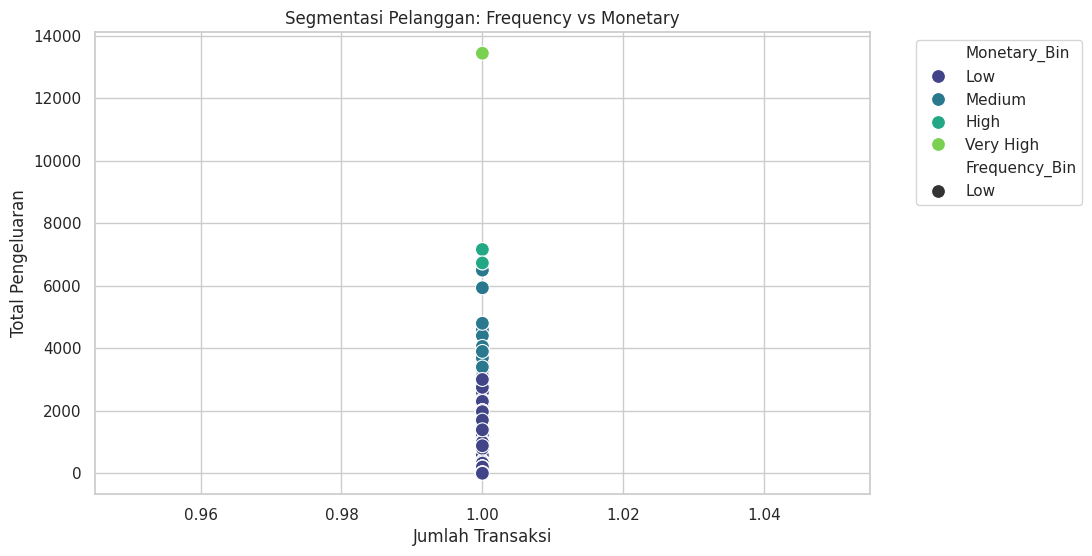

In [49]:
# Binning Monetary
if rfm['Monetary'].nunique() > 1:
    monetary_bins = np.linspace(rfm['Monetary'].min(), rfm['Monetary'].max(), 5)
    rfm['Monetary_Bin'] = pd.cut(rfm['Monetary'], bins=monetary_bins, labels=['Low','Medium','High','Very High'], include_lowest=True)
else:
    rfm['Monetary_Bin'] = 'Medium'

# Binning Frequency
if rfm['Frequency'].nunique() > 1:
    freq_bins = np.linspace(rfm['Frequency'].min(), rfm['Frequency'].max(), 5)
    rfm['Frequency_Bin'] = pd.cut(rfm['Frequency'], bins=freq_bins, labels=['Low','Medium','High','Very High'], include_lowest=True)
else:
    rfm['Frequency_Bin'] = 'Low'

# Visualisasi
plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Monetary_Bin', style='Frequency_Bin', palette='viridis', s=100)
plt.title('Segmentasi Pelanggan: Frequency vs Monetary')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Total Pengeluaran')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

**Insight:**
- Seluruh pelanggan berada pada kategori Low Frequency, yang menunjukkan bahwa 100% basis pelanggan hanya melakukan satu kali pembelian tanpa adanya transaksi berulang (repeat order).

- Meskipun frekuensi transaksi rendah, terdapat sebaran nilai belanja dari kategori Low hingga High, yang mengindikasikan adanya perbedaan daya beli atau variasi harga produk yang dipilih pelanggan dalam sekali transaksi.

- Terdeteksi satu pelanggan di kategori Very High dengan pengeluaran di atas 12.000. Ini adalah aset bernilai tinggi yang perlu dijaga agar tidak menjadi pelanggan sekali beli (one-off customer).

- Fokus utama bisnis perlu bergeser dari sekadar akuisisi pelanggan baru ke strategi loyalitas untuk mendorong transaksi kedua, guna memindahkan posisi pelanggan dari segmen Low ke segmen yang lebih tinggi.

## Conclusion

1. **Perkembangan Transaksi dan Pendapatan**
- Bisnis menunjukkan pertumbuhan yang sangat agresif sepanjang tahun 2017, dengan puncak performa pendapatan terjadi pada November 2017 yang menyentuh angka 1 juta. Meskipun jumlah transaksi (volume) terlihat stabil di level rendah, nilai pendapatan (moneter) berhasil tumbuh berkali-kali lipat. Hal ini menandakan bisnis sukses meningkatkan nilai rata-rata belanja per pelanggan, namun masih memiliki ketergantungan tinggi pada momentum promosi akhir tahun untuk mencapai target pendapatan maksimal.

2. **Karakteristik Pelanggan (Frequency & Monetary)**
- Mayoritas pelanggan memiliki karakteristik sebagai one-time shoppers dengan tingkat loyalitas yang masih rendah, di mana hampir 100% pelanggan hanya melakukan satu kali transaksi tanpa pembelian berulang. Dari sisi pengeluaran, sebagian besar pelanggan masuk dalam kategori small spenders (nilai belanja rendah), namun terdapat kelompok kecil pelanggan "Whale" yang melakukan transaksi tunggal bernilai sangat tinggi (di atas 12.000). Secara keseluruhan, profil pelanggan saat ini didominasi oleh segmen pasif yang memerlukan strategi retensi lebih kuat untuk mendorong transaksi kedua.

In [23]:
rfm.to_csv("main_data.csv", index=False)